In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("Wellbeing_and_lifestyle_data_Kaggle (Dataset1).csv")

In [2]:
df = df[df["DAILY_STRESS"] != '01-01-2000']
df['AGE'] = df['AGE'].map({ "Less than 20": 0, "21 to 35": 1, "36 to 50": 2, "51 or more": 3 })
df['DAILY_STRESS'] = df['DAILY_STRESS'].astype("int64")

features = ['DAILY_STRESS',
'ACHIEVEMENT',
'SLEEP_HOURS',
'DAILY_STEPS',
'AGE',
'DAILY_SHOUTING',
'TIME_FOR_PASSION']

new_df = df[features]

scaler = StandardScaler()

X_scaled2 = scaler.fit_transform(new_df)

wcss = []

for i in range(1,11):

    model = KMeans(n_clusters=i, random_state = 42, n_init=10)
    
    model.fit(X_scaled2)

    wcss.append(model.inertia_)

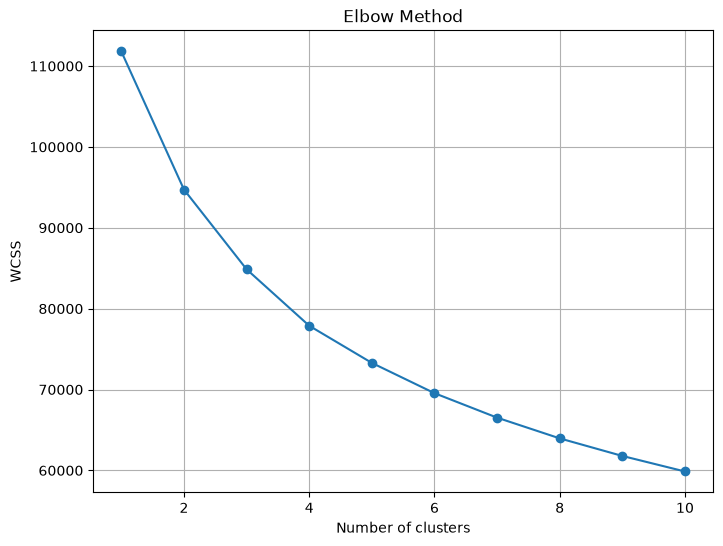

In [3]:
plt.figure(figsize=(8,6))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [4]:
new_df.info()

<class 'pandas.DataFrame'>
Index: 15971 entries, 0 to 15971
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   DAILY_STRESS      15971 non-null  int64
 1   ACHIEVEMENT       15971 non-null  int64
 2   SLEEP_HOURS       15971 non-null  int64
 3   DAILY_STEPS       15971 non-null  int64
 4   AGE               15971 non-null  int64
 5   DAILY_SHOUTING    15971 non-null  int64
 6   TIME_FOR_PASSION  15971 non-null  int64
dtypes: int64(7)
memory usage: 998.2 KB


In [5]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled2)

In [6]:
new_df['clusters'] = clusters
new_df.head(10)

,DAILY_STRESS,ACHIEVEMENT,SLEEP_HOURS,DAILY_STEPS,AGE,DAILY_SHOUTING,TIME_FOR_PASSION,clusters
0,2,2,7,5,2,5,0,0
1,3,5,8,5,2,2,2,0
2,3,3,8,4,2,2,8,1
3,3,2,5,5,3,5,2,4
4,1,2,7,5,3,0,1,0
5,2,2,8,7,3,2,8,0
6,2,3,7,7,3,0,8,0
7,4,4,6,8,1,2,2,4
8,3,5,10,1,1,2,3,3
9,4,0,6,3,3,0,8,4


In [7]:
centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

cluster_centers = pd.DataFrame(
    centers,
    columns=features
)

print(cluster_centers)

   DAILY_STRESS  ACHIEVEMENT  SLEEP_HOURS  DAILY_STEPS       AGE  \
0      2.184765     3.209695     7.354571     5.655679  2.579778   
1      2.495346     7.147179     7.125654     7.019779  1.659104   
2      3.792602     3.298836     6.983791     5.412718  1.450540   
3      2.194725     3.312570     7.658530     5.664703  0.713244   
4      3.783610     2.706739     5.870979     4.513715  1.536742   

   DAILY_SHOUTING  TIME_FOR_PASSION  
0        1.720776          2.631856  
1        2.392379          6.650378  
2        7.726517          2.247298  
3        1.883838          2.697250  
4        2.394175          1.943447  


In [8]:
new_df['clusters'].value_counts()

clusters
0    3606
3    3572
1    3440
4    2947
2    2406
Name: count, dtype: int64

In [9]:
new_df.groupby('clusters')[features].mean()

,DAILY_STRESS,ACHIEVEMENT,SLEEP_HOURS,DAILY_STEPS,AGE,DAILY_SHOUTING,TIME_FOR_PASSION
clusters,,,,,,,
0,2.182474,3.208264,7.355241,5.653356,2.579590,1.720189,2.630338
1,2.495640,7.144477,7.125581,7.020640,1.659012,2.391860,6.650000
2,3.793017,3.295927,6.984206,5.409393,1.450125,7.726933,2.245220
3,2.196529,3.309071,7.657335,5.655095,0.713606,1.883539,2.694569
4,3.786563,2.714286,5.867662,4.526637,1.540550,2.395996,1.946386


In [10]:
overall_mean = new_df[features].mean()

overall_std = new_df[features].std()

cluster_profile = (
    new_df.groupby('clusters')[features].mean()
    - overall_mean
) / overall_std

print(cluster_profile)

          DAILY_STRESS  ACHIEVEMENT  SLEEP_HOURS  DAILY_STEPS       AGE  \
clusters                                                                  
0            -0.445395    -0.287536     0.260446    -0.017375  1.035018   
1            -0.216439     1.140743     0.068911     0.455554  0.060270   
2             0.732075    -0.255727    -0.048994    -0.101759 -0.160909   
3            -0.435119    -0.250958     0.512389    -0.016773 -0.940768   
4             0.727356    -0.466779    -0.980182    -0.407094 -0.065163   

          DAILY_SHOUTING  TIME_FOR_PASSION  
clusters                                    
0              -0.452413         -0.255005  
1              -0.201446          1.217869  
2               1.791974         -0.396119  
3              -0.391378         -0.231470  
4              -0.199901         -0.505617  


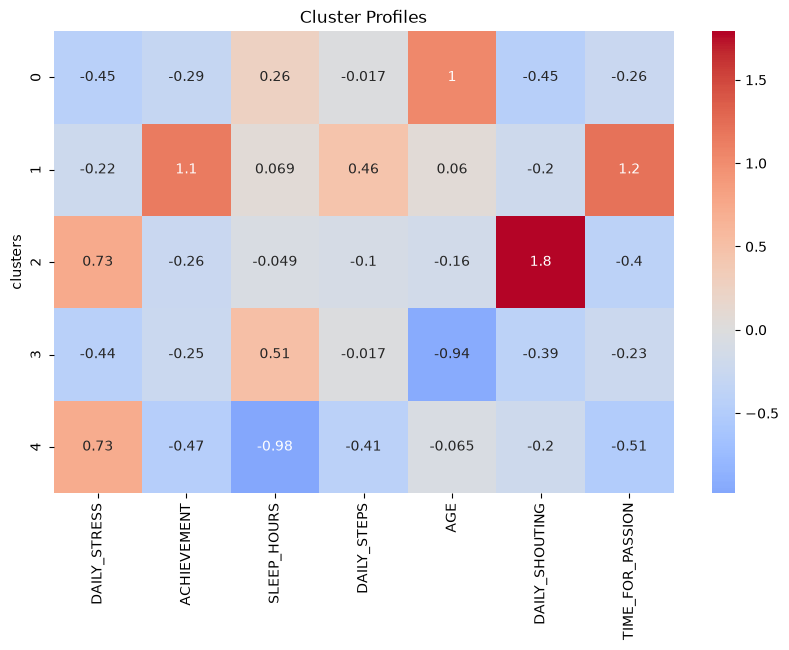

In [11]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Cluster Profiles")
plt.show()

In [12]:
feature_importance = cluster_profile.abs().max(axis=0)

feature_importance.sort_values(ascending=False)

DAILY_SHOUTING      1.791974
TIME_FOR_PASSION    1.217869
ACHIEVEMENT         1.140743
AGE                 1.035018
SLEEP_HOURS         0.980182
DAILY_STRESS        0.732075
DAILY_STEPS         0.455554
dtype: float64

In [13]:
# Plotting the sse of clusters

for cluster_id in range(kmeans.n_clusters):
    
    #selecting the cluster points
    cluster_points = X_scaled2[clusters == cluster_id]

    #Getting centroid
    cluster_centers =  kmeans.cluster_centers_[cluster_id]

    #Calculate SSE
    sse = np.sum((cluster_points-cluster_centers)**2)

    print(f"Cluster {cluster_id}: SSE = {sse:.2f}")

Cluster 0: SSE = 14507.98
Cluster 1: SSE = 18987.26
Cluster 2: SSE = 12660.68
Cluster 3: SSE = 14150.28
Cluster 4: SSE = 12983.82


In [14]:
#Finding the diameter of the cluster

from sklearn.metrics import pairwise_distances_chunked

def cluster_diameter(points):

    max_distance = 0

    for distances in pairwise_distances_chunked(
        points,
        working_memory=256
    ):
        max_distance = max(
            max_distance,
            distances.max()
        )

    return max_distance


for cluster_id in range(kmeans.n_clusters):

    points = X_scaled2[clusters == cluster_id]

    diameter = cluster_diameter(points)

    print(
        f"Cluster {cluster_id}: "
        f"Diameter = {diameter:.3f}"
    )

Cluster 0: Diameter = 7.405
Cluster 1: Diameter = 9.547
Cluster 2: Diameter = 8.440
Cluster 3: Diameter = 7.632
Cluster 4: Diameter = 8.149


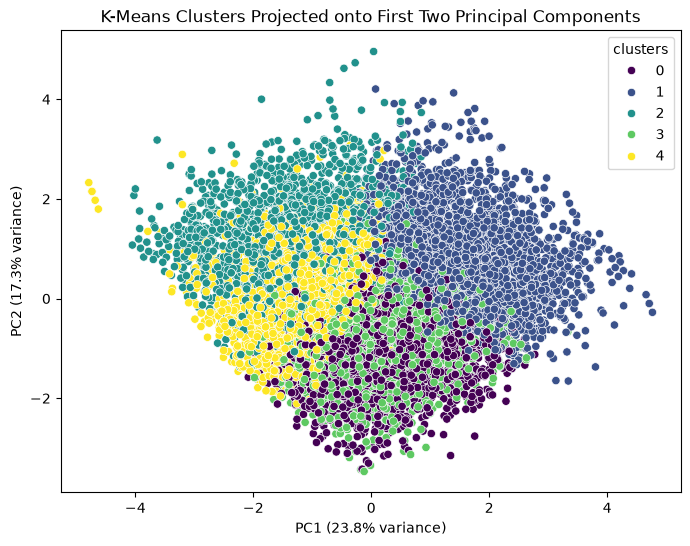

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled2)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=new_df['clusters'],
    palette='viridis'
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)"
)
plt.title("K-Means Clusters Projected onto First Two Principal Components")

plt.show()

In [16]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled2, clusters)

print(score)

0.12044028688690346


In [17]:
from sklearn.metrics import davies_bouldin_score

score = davies_bouldin_score(X_scaled2, clusters)

print(score)

1.8840146156212694


In [18]:
from sklearn.metrics import calinski_harabasz_score

score = calinski_harabasz_score(X_scaled2, clusters)

print(score)

2097.1770188678215


In [19]:
ch_scores = []
db_scores = []

for i in range(2,11):

    kmeans = KMeans(n_clusters=i, random_state = 42, n_init=10)
    
    labels = kmeans.fit_predict(X_scaled2)

    ch_scores.append(calinski_harabasz_score(X_scaled2, labels))
    db_scores.append(davies_bouldin_score(X_scaled2, labels))

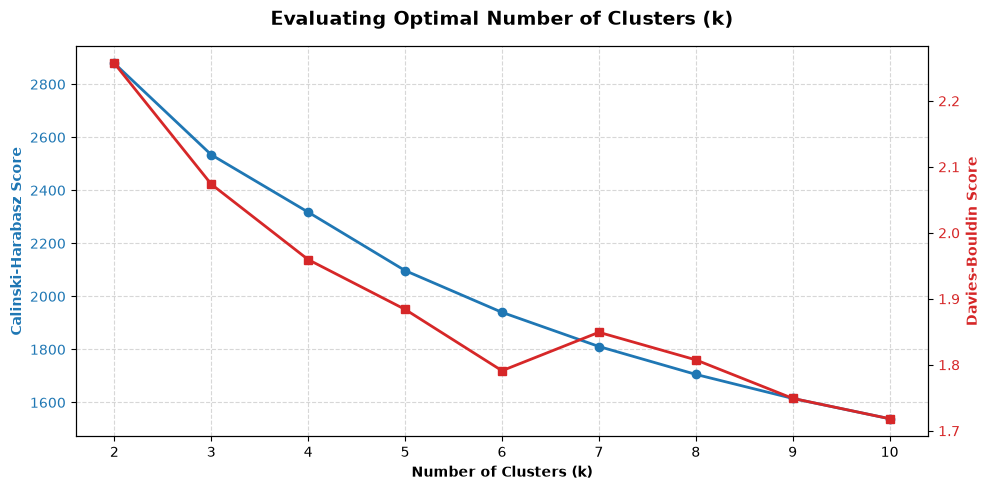

In [20]:
# Plot the evaluation metrics
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Calinski-Harabasz Score (Higher is Better)
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)', fontweight='bold')
ax1.set_ylabel('Calinski-Harabasz Score', color=color, fontweight='bold')
ax1.plot(range(2, 11), ch_scores, marker='o', color=color, linewidth=2, label='CH Score (Maximize)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()  

# Plot Davies-Bouldin Score (Lower is Better)
color = 'tab:red'
ax2.set_ylabel('Davies-Bouldin Score', color=color, fontweight='bold')
ax2.plot(range(2, 11), db_scores, marker='s', color=color, linewidth=2, label='DB Score (Minimize)')
ax2.tick_params(axis='y', labelcolor=color)

# Title and layout adjustments
plt.title('Evaluating Optimal Number of Clusters (k)', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

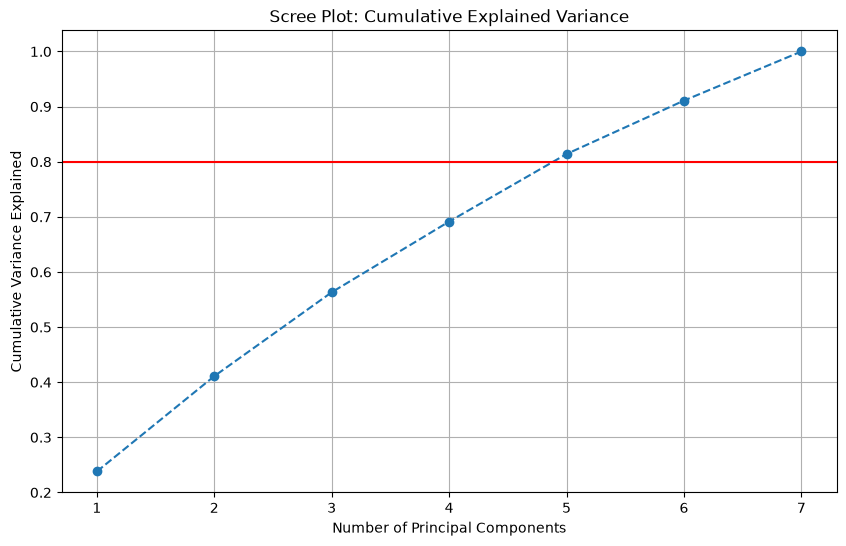

In [21]:
pca_full = PCA()
pca_full.fit_transform(X_scaled2)

# 3. Calculate Explained Variance
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# 4. Plot the Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.80, color='r', linestyle='-') # 80% variance threshold
plt.title('Scree Plot: Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid()
plt.show()

Variance explained by PC1: 23.80%
Variance explained by PC2: 17.29%
Total variance captured in this 2D plot: 41.09%


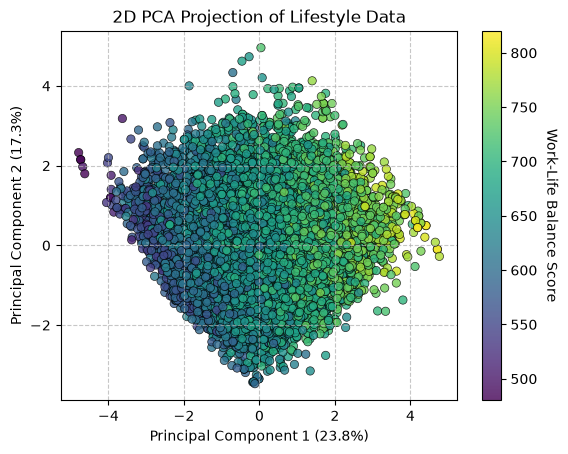

In [22]:
y = df['WORK_LIFE_BALANCE_SCORE']
PCA_DF = pd.DataFrame(data = pca_full.transform(X_scaled2)[:, :3], columns=['PC1', 'PC2', 'PC3'])
PCA_DF['Target'] = y.values

var_explained = pca_full.explained_variance_ratio_
print(f"Variance explained by PC1: {var_explained[0]*100:.2f}%")
print(f"Variance explained by PC2: {var_explained[1]*100:.2f}%")
print(f"Total variance captured in this 2D plot: {(var_explained[0]+var_explained[1])*100:.2f}%")
scatter = plt.scatter(PCA_DF['PC1'], PCA_DF['PC2'], c=PCA_DF['Target'], cmap='viridis', 
                      alpha=0.8, # Make dots slightly transparent to see overlapping
                      edgecolors='black', 
                      linewidth=0.5)

# Add a color bar to explain the colors
cbar = plt.colorbar(scatter)
cbar.set_label('Work-Life Balance Score', rotation=270, labelpad=15)

# Labels and Title
plt.xlabel(f'Principal Component 1 ({var_explained[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({var_explained[1]*100:.1f}%)')
plt.title('2D PCA Projection of Lifestyle Data')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()